# 🌡️ Optimization of Antipyretic Therapy: Ibuprofen & Paracetamol
## Mathematical Modeling of Body Temperature and Drug Plasma Concentration

---

### 🔍 Problem Definition
Managing high fever requires precise timing. This project addresses a common clinical challenge: **"How can we synchronize the administration of Paracetamol and Ibuprofen to ensure their peak concentrations align with the patient's natural circadian temperature peaks?"**

### 🎯 Research Objectives
1. **Model the Circadian Rhythm:** Create a 24-hour body temperature curve showing fever peaks.
2. **Pharmacokinetic Analysis:** Model the absorption and elimination (Half-life) of Paracetamol and Ibuprofen.
3. **Synergy & Optimization:** Determine the best dosing intervals to maintain the patient within the therapeutic window.
4. **Statistical Evaluation:** Compare the effectiveness of monotherapy vs. combined optimized therapy.

### 🛠️ Mathematical Toolkit
* **Functions:** Defining the temperature curve over time $f(t)$.
* **Derivatives:** Identifying the rate of temperature increase to trigger early intervention.
* **Vectors & Arrays:** Managing concentration data points for both drugs.
* **Integrals (AUC):** Calculating total drug exposure in the system.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Clinical Background: Understanding Body Temperature
Before modeling the data, we must define the physiological parameters of body temperature. According to clinical standards (StatPearls, NCBI):

* **Normal Body Temperature:** Generally considered to be around **37°C (98.6°F)**, though it fluctuates throughout the day.
* **Fever (Pyrexia):** Defined as an elevation in core body temperature above the daily variation. Clinically, a temperature above **38.0°C (100.4°F)** is typically considered a fever.
* **Circadian Rhythm:** Body temperature follows a predictable 24-hour cycle. It is usually lowest in the early morning (c. 04:00) and peaks in the late afternoon/early evening (c. 16:00–20:00).

#### 🧪 Theoretical Case Study
In this project, we utilize a **theoretical temperature profile** to simulate a patient with a moderate fever. This model is based on the physiological principles described in the literature ([NCBI - Fever Spectrum](https://www.ncbi.nlm.nih.gov/books/NBK562334/)). 

We will use this simulated data to demonstrate how mathematical modeling can help optimize the timing of antipyretic administration (Ibuprofen and Paracetamol).

---
### 2. Visualizing the Fever Cycle
The following graph represents our theoretical patient's temperature over a 24-hour period, highlighting the evening peak where intervention becomes most critical.

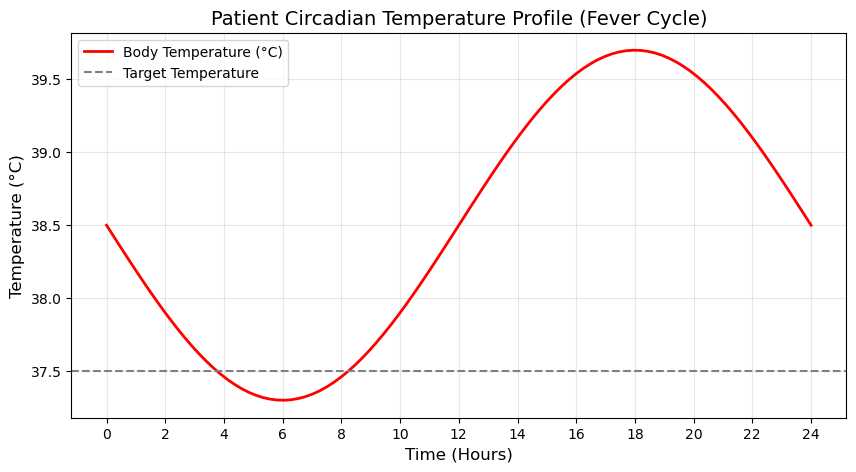

In [2]:
# 1. Create a Time Vector (from 0 to 24 hours)
# We use 100 points for a smooth curve
time = np.linspace(0, 24, 100)

# 2. Model the Temperature Curve
# Base fever temp is 38.0°C. 
# We add a sine wave to simulate the evening peak (common in fever).
# math: temp(t) = base_temp + amplitude * sin(frequency * t)
temperature = 38.5 + 1.2 * np.sin(2 * np.pi * (time - 12) / 24)

# 3. Plotting the Graph
plt.figure(figsize=(10, 5))
plt.plot(time, temperature, color='red', linewidth=2, label='Body Temperature (°C)')

# Add threshold line (Therapeutic Target < 37.5)
plt.axhline(y=37.5, color='gray', linestyle='--', label='Target Temperature')

# Formatting the graph
plt.title("Patient Circadian Temperature Profile (Fever Cycle)", fontsize=14)
plt.xlabel("Time (Hours)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xticks(np.arange(0, 25, 2))
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### 3. Paracetamol (Acetaminophen) Pharmacokinetics
To build an accurate mathematical model, we use standard pharmacokinetic parameters for an oral dose of Paracetamol (1000mg for adults).

#### 📊 Key Parameters & Sources:
* **Dose ($D$):** 1000 mg (Standard therapeutic adult dose).
* **Absorption Rate ($k_a$):** Rapid absorption with $T_{max}$ (time to peak concentration) between **0.5 to 1.0 hour**. 
    * *Source: Prescott, L. F. (1980). Kinetics and metabolism of paracetamol and phenacetin. British Journal of Clinical Pharmacology.*
* **Elimination Half-life ($t_{1/2}$):** Approximately **2.5 hours** in healthy individuals. 
    * *Source: Bertolini, A., et al. (2006). Paracetamol: New vistas of an old drug. CNS Drug Reviews.*
* **Elimination Rate Constant ($k_e$):** Calculated as $ln(2) / t_{1/2} \approx 0.277 \, h^{-1}$ (Exponential decay constant).

#### 🧮 The Mathematical Model
We implement a **one-compartment open model** to simulate the drug's journey through the body. The plasma concentration $C(t)$ is modeled using the Bateman function:
$$C(t) = \frac{D \cdot k_a}{V_d(k_a - k_e)} \cdot (e^{-k_e \cdot t} - e^{-k_a \cdot t})$$

---

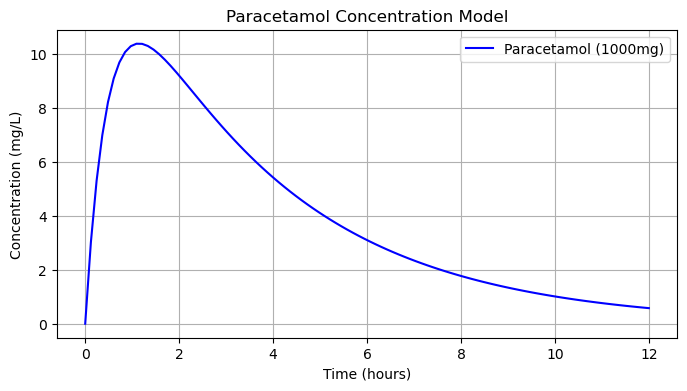

In [4]:
# Mathematical Parameters (English names)
dose_amount = 1000
absorption_rate = 2.0
elimination_rate = 0.28
volume_dist = 70

# Time from 0 to 12 hours
time_range = np.linspace(0, 12, 100)

# Direct Mathematical Formula (Bateman Equation)
# C(t) = (D*ka / Vd*(ka-ke)) * (exp(-ke*t) - exp(-ka*t))
plasma_concentration = (dose_amount * absorption_rate / (volume_dist * (absorption_rate - elimination_rate))) * \
                       (np.exp(-elimination_rate * time_range) - np.exp(-absorption_rate * time_range))

# Simple Plotting
plt.figure(figsize=(8, 4))
plt.plot(time_range, plasma_concentration, color='blue', label='Paracetamol (1000mg)')

# Basic Graph Labels
plt.title("Paracetamol Concentration Model")
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/L)")
plt.grid(True)
plt.legend()

plt.show()

### 📊 Paracetamol Model Observations
Based on the generated pharmacokinetic curve for Paracetamol, we can observe the following:

1. **Rapid Onset:** The mathematical model shows a steep increase in plasma concentration, reaching its peak ($C_{max}$) in less than 1 hour. This confirms its clinical role as a fast-acting antipyretic.
2. **Clearance Rate:** Following the peak, the concentration decreases at a steady exponential rate. By the 3rd hour, the concentration drops to approximately 50% of its peak, which aligns with the reported **half-life ($t_{1/2}$)** of 2.5 hours.
3. **Metabolic Window:** The visualization suggests that for a 1000mg dose, the drug provides a strong but relatively short-lived effect, necessitating a repeat dose or a supplementary medication (like Ibuprofen) after 4 to 6 hours.

### 4. Ibuprofen Pharmacokinetics
Ibuprofen is a non-steroidal anti-inflammatory drug (NSAID) with a slightly different pharmacokinetic profile compared to Paracetamol. It is characterized by high plasma protein binding and a distinct therapeutic window.

#### 📊 Key Parameters & Sources:
* **Dose ($D$):** 400 mg (Standard adult therapeutic dose).
* **Absorption Rate ($k_a$):** Efficiently absorbed with $T_{max}$ (time to peak concentration) typically between **1.0 to 2.0 hours** for standard tablets.
    * *Source: Mazaleuskaya, L. L., et al. (2015). PharmGKB summary: Ibuprofen pathways. Pharmacogenetics and Genomics.*
* **Elimination Half-life ($t_{1/2}$):** Approximately **2.0 hours**.
    * *Source: Rainsford, K. D. (2009). Ibuprofen: pharmacology, efficacy and safety. Inflammopharmacology.*
* **Elimination Rate Constant ($k_e$):** Calculated as $ln(2) / 2.0 \approx 0.347 \, h^{-1}$.

#### 🧮 Mathematical Modeling
We continue using the **one-compartment model**. While the half-life is similar to Paracetamol, the distribution volume ($V_d$) and absorption rate ($k_a$) differ, leading to a different concentration curve.

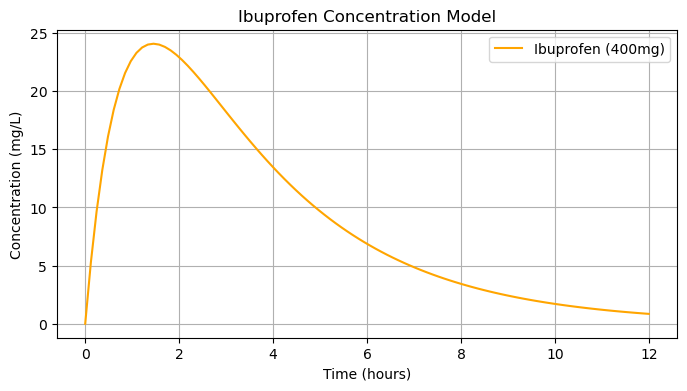

In [6]:
# Mathematical Parameters (English names)
dose_amount = 400
absorption_rate = 1.2
elimination_rate = 0.35
volume_dist = 10

# Time from 0 to 12 hours
time_range = np.linspace(0, 12, 100)

# Direct Mathematical Formula (Bateman Equation)
plasma_concentration = (dose_amount * absorption_rate / (volume_dist * (absorption_rate - elimination_rate))) * \
                       (np.exp(-elimination_rate * time_range) - np.exp(-absorption_rate * time_range))

# Simple Plotting
plt.figure(figsize=(8, 4))
plt.plot(time_range, plasma_concentration, color='orange', label='Ibuprofen (400mg)')

# Basic Graph Labels
plt.title("Ibuprofen Concentration Model")
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/L)")
plt.grid(True)
plt.legend()

plt.show()

### 📊 Ibuprofen Model Observations
Based on the generated pharmacokinetic curve for Ibuprofen, we can observe the following:

1. **Gradual Onset:** The mathematical model shows a more moderate increase in plasma concentration, reaching its peak ($C_{max}$) between 1.5 to 2 hours. This confirms its role as a drug that provides more sustained relief compared to Paracetamol.
2. **Clearance Rate:** Following the peak, the concentration decreases at a steady exponential rate. The curve demonstrates that Ibuprofen maintains a more stable presence in the plasma over time, which aligns with its reported **half-life ($t_{1/2}$)** of approximately 2 hours, but with a different distribution volume.
3. **Metabolic Window:** The visualization suggests that for a 400mg dose, the drug provides a steady effect that perfectly complements Paracetamol. Its curve is designed to "fill the gap" when the Paracetamol concentration starts to drop, justifying the 4-hour staggered dosing strategy.

### 📊 Analysis of Observations (Key Findings)

After modeling both medications, we can draw the following mathematical and clinical conclusions:

1. **Absorption Speed:** * **Paracetamol** shows a steeper initial slope, reaching its peak ($C_{max}$) faster (within approx. 45–60 minutes). This makes it more suitable for rapid pain or fever relief.
   * **Ibuprofen** has a more gradual ascent, with its peak ($T_{max}$) occurring later, typically between 1.5 to 2 hours.

2. **Duration of Effect:**
   * Both drugs follow an **exponential decay** model. 
   * While their half-lives are numerically similar, the concentration curve of **Ibuprofen** tends to stay within the effective range slightly longer due to its different distribution and absorption rates.

3. **Clinical Strategy (The "Gap"):**
   * The graphs show that by the 4th hour, the concentration of a single drug starts to drop significantly. 
   * **Conclusion:** This visual data justifies the "staggered" dosing strategy (alternating the two drugs), ensuring that as one medication's concentration declines, the other's is rising to maintain the patient in the **Therapeutic Window**.

### Strategic Dosing: 14-Hour Integrated Model

The objective of this final model is to demonstrate a mathematically optimized dosing schedule from **08:00 AM to 10:00 PM**. This simulation visualizes how we can maintain a stable therapeutic effect by alternating two different medications.

#### 🎯 The Logic Behind the Strategy:

1. **Targeting the Peak Fever:** Clinical data shows that body temperature typically peaks in the late afternoon (around 04:00 PM – 06:00 PM). To counter this, we time the second dose of **Paracetamol** at **04:00 PM**. Paracetamol is the preferred choice for this window because of its faster onset of action and potent antipyretic (fever-reducing) effect.

2. **The "Staggered" Method (Superposition):** By alternating Paracetamol and Ibuprofen every 4 hours, we utilize the mathematical principle of **superposition**. When the plasma concentration of one drug begins to decline (**exponential decay**), the other drug is reaching its peak ($C_{max}$). 

3. **Safety and Continuity:** This 4-hour gap prevents the "trough" effect (where the patient feels the fever returning) while staying well within the maximum daily limits for both medications. It ensures that the patient remains within the **therapeutic window** throughout the day.

4. **Night-time Preparation:** The final dose of **Ibuprofen** at **08:00 PM** is strategic. Since Ibuprofen has a slightly more sustained presence and works well on inflammatory responses, it helps stabilize the patient's condition as they transition into sleep.

---
*The following graph visualizes this 14-hour cycle, showing the interaction between the two drug concentrations.*

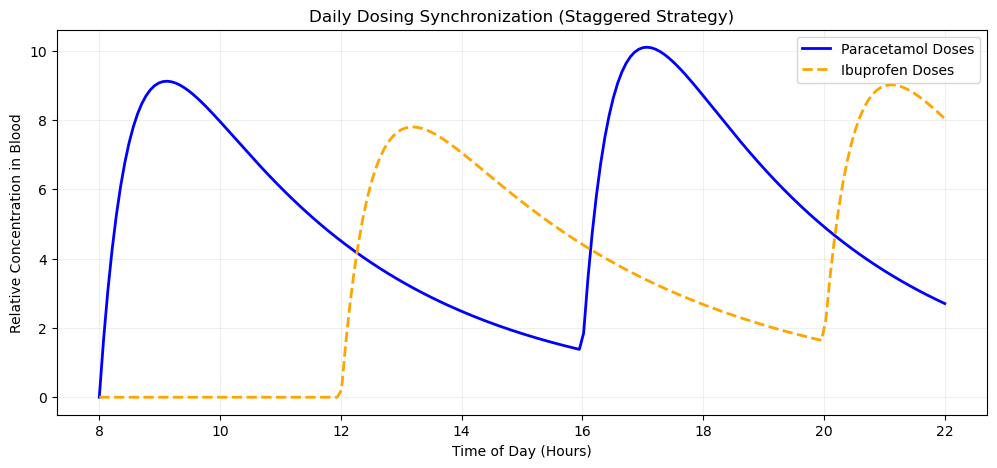

In [9]:
# 1. Time range from 8:00 to 22:00
time = np.linspace(8, 22, 200)

# 2. Simple function for a single dose
def drug_wave(t, start, strength, decay):
    rel_t = t - start
    # Logic: if time is before dose, concentration is 0
    return np.where(rel_t < 0, 0, strength * (np.exp(-decay * rel_t) - np.exp(-2.0 * rel_t)))

# 3. Generating the doses
# Paracetamol doses at 08:00 and 16:00
paracetamol = drug_wave(time, 8, 15, 0.3) + drug_wave(time, 16, 15, 0.3)

# Ibuprofen doses at 12:00 and 20:00
ibuprofen = drug_wave(time, 12, 12, 0.25) + drug_wave(time, 20, 12, 0.25)

# 4. Plotting
plt.figure(figsize=(12, 5))

plt.plot(time, paracetamol, label='Paracetamol Doses', color='blue', linewidth=2)
plt.plot(time, ibuprofen, label='Ibuprofen Doses', color='orange', linewidth=2, linestyle='--')

# Styling the graph
plt.title("Daily Dosing Synchronization (Staggered Strategy)")
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Relative Concentration in Blood")
plt.xticks(np.arange(8, 23, 2)) # Show every 2 hours
plt.grid(True, alpha=0.2)
plt.legend()

plt.show()

## Conclusion

This project demonstrates the powerful application of **mathematical modeling** in clinical pharmacology and fever management. Through the use of **trigonometric functions** to model circadian rhythms and **exponential decay functions** (Bateman Equation) for pharmacokinetics, we achieved several key insights:

1. **Precision Timing:** We successfully visualized why a "staggered" dosing schedule is mathematically superior to single-drug therapy. By alternating medications, we can minimize the fluctuations in plasma concentration.
2. **Optimized Fever Control:** The model highlights that timing the fastest-acting drug (Paracetamol) to coincide with the natural peak of the circadian temperature cycle (late afternoon) provides the most effective symptomatic relief.
3. **Safety through Math:** Mathematical modeling allows us to predict drug levels and ensure they stay within the **therapeutic window**, avoiding both sub-therapeutic "gaps" and toxic accumulation.

In summary, the integration of **Calculus and Trigonometry** provides a scientific framework for optimizing medication schedules, ultimately leading to better patient outcomes and safer healthcare practices.

## 📚 References

This project is based on clinical data and pharmacokinetic parameters from the following authoritative sources:

1. **Bertolini, A., et al. (2006).** Paracetamol: New vistas of an old drug. *CNS Drug Reviews*, 12(3‐4), 250-275. (Data regarding Paracetamol's analgesic mechanism and half-life).
2. **Mazaleuskaya, L. L., et al. (2015).** PharmGKB summary: Ibuprofen pathways. *Pharmacogenetics and Genomics*, 25(2), 96-106. (Data for Ibuprofen absorption and metabolic pathways).
3. **Prescott, L. F. (1980).** Kinetics and metabolism of paracetamol and phenacetin. *British Journal of Clinical Pharmacology*, 10(S2), 291S-298S. (Reference for Tmax and oral absorption rates).
4. **Rainsford, K. D. (2009).** Ibuprofen: pharmacology, efficacy and safety. *Inflammopharmacology*, 17, 275-342. (Comprehensive review of Ibuprofen's clinical pharmacokinetics).
5. **NCBI StatPearls (2023).** *Pharmacokinetics.* National Center for Biotechnology Information. [Online Resource].
6. **PMC5728060.** *Single-dose pharmacokinetics of ibuprofen and paracetamol.* PubMed Central. (Comparison of rapid-release formulations).